In [34]:
import pandas as pd

# Load the CSV file to check its contents
file_path = r"C:\Users\Lenovo\final_dummy_data.csv"
data = pd.read_csv(file_path)

# Display the first few rows of the dataframe to understand its structure
data


,User_ID,User_Name,Email,Phone_Number,Registration_Date,Avg_Usage_Min,Avg_Notifications,Avg_Times_Opened
0,1891b76f-433d-4ab4-924c-fe62ee9f392a,Michelle Ward,megan21@example.org,001-676-290-7404,2022-05-20,204,90,49
1,714c5cda-c977-4d11-bcbd-38d96f66e2be,Mr. Mario Miller,frankjohnny@example.com,001-608-480-7862,2022-01-25,295,9,42
2,653f2335-0d96-462e-a8ef-915009041a64,Matthew Lopez,lindsaytaylor@example.org,750.450.8530,2021-05-28,52,89,6
3,57ddae82-d521-46fa-9357-d6ea109821ed,Henry Miller,michaelsmith@example.com,304.594.3246,2023-04-20,486,65,23
4,05c2df21-a5cc-40ec-a5be-fc356a69fe1d,Mr. Joseph Davis DDS,williamstina@example.org,502.825.5298x55562,2020-09-10,125,18,10
...,...,...,...,...,...,...,...,...
99995,3487970b-1e58-4797-a421-f8f0371c01c9,Sabrina Green,georgetaylor@example.org,(288)928-2440,2023-12-14,175,61,15
99996,b41176ed-3021-4f0c-9748-1a56977c2818,Linda Hammond,karenpeters@example.org,284.677.9636x86083,2022-12-20,446,92,18
99997,e67e56e2-6ccc-4db0-9707-6b0378b81c70,Jessica Gonzalez,jacksonjuan@example.com,(949)346-3505x586,2024-08-23,33,38,38
99998,9c662c08-28c2-44af-b7bb-8ccec7ac4736,Patricia Carter,longchristopher@example.org,523.970.7224,2021-06-06,468,5,4


In [35]:
# Define user profiles with behavior patterns
user_profiles = {
    "Casual User": {"usage_range": (0, 30), "notifications_range": (0, 50), "opens_range": (1, 10)},
    "Heavy User": {"usage_range": (60, 120), "notifications_range": (100, 300), "opens_range": (30, 60)},
    "Business User": {"usage_range": (30, 60), "notifications_range": (20, 100), "opens_range": (20, 40)},
    "Social Media Enthusiast": {"usage_range": (90, 150), "notifications_range": (200, 500), "opens_range": (50, 100)},
    "Minimalist": {"usage_range": (0, 15), "notifications_range": (0, 20), "opens_range": (1, 5)},
}



In [36]:
def simulate_user_data(start_date, num_days, app_name, user_profiles):
    data = []
    current_date = start_date
    for _ in range(num_days):
        for profile, behavior in user_profiles.items():
            usage = random.randint(*behavior["usage_range"])
            notifications = random.randint(*behavior["notifications_range"])
            times_opened = random.randint(*behavior["opens_range"])
            data.append([current_date.strftime('%m/%d/%Y'), usage, notifications, times_opened, app_name, profile])
        current_date += timedelta(days=1)
    return pd.DataFrame(data, columns=["Date", "Usage", "Notifications", "Times opened", "App", "User Profile"])

# Simulate data
simulated_data = simulate_user_data(start_date, num_days, "Instagram", user_profiles)


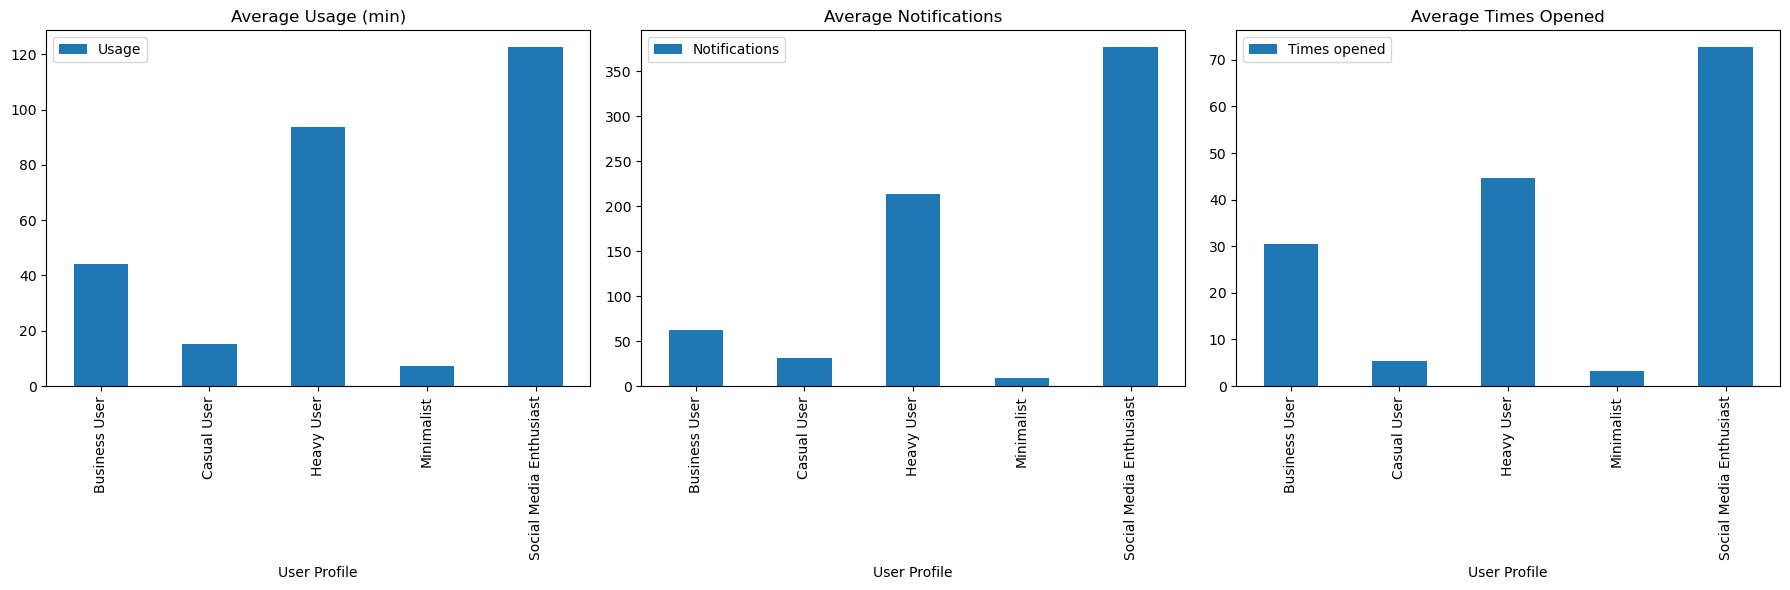

In [37]:

# Analyze profile usage patterns
profile_usage_patterns = simulated_data.groupby('User Profile').agg({
    'Usage': 'mean',
    'Notifications': 'mean',
    'Times opened': 'mean'
}).reset_index()

# Plot the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
profile_usage_patterns.plot(kind='bar', x='User Profile', y='Usage', ax=axes[0], title="Average Usage (min)")
profile_usage_patterns.plot(kind='bar', x='User Profile', y='Notifications', ax=axes[1], title="Average Notifications")
profile_usage_patterns.plot(kind='bar', x='User Profile', y='Times opened', ax=axes[2], title="Average Times Opened")
plt.tight_layout()
plt.show()


In [38]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv(r"C:\Users\Lenovo\final_dummy_data.csv")

# Define the simulation period (1 month)
start_date = dt.datetime(2024, 8, 1)
end_date = dt.datetime(2024, 8, 31)
date_range = pd.date_range(start_date, end_date)

# Create an empty DataFrame to hold the simulated data
simulation_data = pd.DataFrame()

# Define factors like work hours, weekends, and holidays
work_hours = list(range(9, 18))  # 9 AM to 6 PM
weekends = [5, 6]  # Saturday and Sunday
holidays = [dt.datetime(2024, 8, 15)]  # Example holiday (e.g., Independence Day)

# Function to simulate daily usage based on profile
def simulate_usage(profile, day):
    if day.weekday() in weekends or day in holidays:
        # Less usage on weekends and holidays
        usage_factor = 0.5
    else:
        # Adjust usage during work hours for different profiles
        if profile == 'Business':
            usage_factor = 1.5 if day.hour in work_hours else 0.7
        elif profile == 'Heavy':
            usage_factor = 1.8
        elif profile == 'Casual':
            usage_factor = 0.7
        elif profile == 'Social Media Enthusiast':
            usage_factor = 1.6
        else:  # Minimalist
            usage_factor = 0.5

    # Simulate daily usage data
    avg_usage = np.random.randint(10, 300) * usage_factor
    avg_notifications = np.random.randint(1, 80) * usage_factor
    avg_times_opened = np.random.randint(1, 20) * usage_factor

    return avg_usage, avg_notifications, avg_times_opened

# Simulate for each user
for index, user in df.iterrows():
    for day in date_range:
        usage, notifications, times_opened = simulate_usage(user['Profile_Type'], day)
        simulation_data = simulation_data.append({
            'User_ID': user['User_ID'],
            'Date': day,
            'Profile_Type': user['Profile_Type'],
            'Avg_Usage_Min': usage,
            'Avg_Notifications': notifications,
            'Avg_Times_Opened': times_opened
        }, ignore_index=True)

# Save the simulated data
simulation_data.to_csv('/mnt/data/simulated_user_behavior.csv', index=False)
print("Simulated user behavior data saved.")

# Analyze and visualize the simulated data
profile_group = simulation_data.groupby('Profile_Type').mean()

# Plot average usage by profile type
profile_group['Avg_Usage_Min'].plot(kind='bar', title='Average Usage by Profile Type')
plt.xlabel('Profile Type')
plt.ylabel('Average Usage (Minutes)')
plt.show()

# Plot average notifications by profile type
profile_group['Avg_Notifications'].plot(kind='bar', title='Average Notifications by Profile Type')
plt.xlabel('Profile Type')
plt.ylabel('Average Notifications')
plt.show()

# Plot average times opened by profile type
profile_group['Avg_Times_Opened'].plot(kind='bar', title='Average Times Opened by Profile Type')
plt.xlabel('Profile Type')
plt.ylabel('Average Times Opened')
plt.show()


KeyError: 'Profile_Type'

In [40]:
import pandas as pd
import numpy as np
from faker import Faker

fake = Faker()

# Generate data
num_records = 40000
date_range = pd.date_range(start='2023-01-01', end='2023-12-31', periods=num_records)
usage = np.random.randint(1, 100, num_records)
notification = np.random.choice([True, False], num_records)
time_opened = [fake.time() for _ in range(num_records)]
apps = ['Facebook', 'Instagram', 'Twitter', 'LinkedIn', 'TikTok']
app = np.random.choice(apps, num_records)

# Create DataFrame
df = pd.DataFrame({
    'date': date_range,
    'usage': usage,
    'notification': notification,
    'time_opened': time_opened,
    'app': app
})

# Save to CSV
df.to_csv('dummy_data1.csv', index=False)


In [47]:
import pandas as pd
import numpy as np
from faker import Faker
from datetime import datetime, timedelta

fake = Faker()

# Generate data
num_records = 10000
start_date = datetime(2023, 1, 1)
end_date = datetime(2023, 12, 31)

usage = np.random.randint(1, 100, num_records)
notification = np.random.randint(0, 20, num_records)
times_opened = np.random.randint(1, 50, num_records)
apps = ['Facebook', 'Instagram', 'Twitter', 'LinkedIn', 'TikTok', 'WhatsApp', 'Snapchat', 'YouTube']
app = np.random.choice(apps, num_records)

# Create DataFrame
df = pd.DataFrame({
    'usage': usage,
    'notification': notification,
    'times_opened': times_opened,
    'app': app
})

# Format date as m/d/y
# df['date'] = pd.to_datetime(df['date'], errors='coerce')
# df['date'] = df['date'].dt.strftime('%mm/%dd/%yyyy')

# Save to CSV
df.to_csv('b_dummy_data.csv', index=False)

print(df.head())

   usage  notification  times_opened        app
0     29            10             4   Snapchat
1     75            16            18     TikTok
2     53             1            22     TikTok
3     15             3             8  Instagram
4     64            12             5     TikTok
